# Cuantización a int8 para TFLite Micro

**Proyecto Final de Ingeniería en Electrónica — FaCENA-UNNE**
(Red de sensores LoRa para detección temprana de incendios)

Toma el modelo que entrena `4.red_entrenada.ipynb` —un `.keras` en float32 que da
P(`fuego`) y P(`humo`)— y produce lo que se compila en el nodo ESP32-S3: un `.tflite`
**full-int8** para `esp-tflite-micro`, el mismo modelo como array de C y un
`cuantizacion.json` con las escalas y la regla de decisión. En el camino mide **al modelo
cuantizado**, que es el que va a correr, y no al float.

Está separado del entrenamiento porque tiene otro ritmo: entrenar lleva decenas de
minutos de GPU; cuantizar, medir y ajustar el umbral lleva algunos minutos de CPU y se
repite cada vez que cambia algo del lado del nodo (la calibración, el umbral, el
objetivo de pérdidas) sin tener que volver a entrenar.

| Entra | Sale (en `salidas/modelos/`) |
|---|---|
| el `cnn_fuego_*.keras` más reciente | `modelo_int8.tflite`, `modelo_int8.cc`, `cuantizacion.json` |

**Recorrido:** datos y modelo → exportación int8 → evaluación int8 y "como lo ve la
cámara" → umbral de decisión → entregables.

## 1. Datos y modelo

Todo corre en **CPU**: ni la conversión ni el intérprete TFLite usan la GPU, y así este
notebook no depende de la cuDNN ni le disputa la memoria de la GTX 1050 a un
entrenamiento.

Los datos se arman con `modulos/dfire.py`, **el mismo módulo que usa el entrenamiento**:
la calibración int8 y la evaluación del modelo cuantizado tienen que ver las imágenes
preprocesadas exactamente como las vio la red al entrenar (reducción bilineal con
*antialias*, redondeo a uint8). Una diferencia ahí no rompe nada visible: corre los
rangos int8 y la exactitud cae en silencio.

La partición es la oficial del banco, y las métricas que valen son las del subconjunto
**sin gemelos** de entrenamiento, tanto en prueba como en validación (§6bis del
notebook 4). El modelo es el `.keras` más reciente que dejó el notebook 4.

In [1]:
import os

# Todo en CPU: la conversión y el intérprete TFLite no usan GPU, y así este notebook no
# depende de la cuDNN ni compite por la memoria de la GTX 1050 con un entrenamiento.
# Tiene que ir ANTES de importar TensorFlow.
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from tensorflow import keras

MODULOS = Path("../modulos") if Path("../modulos").exists() else Path("modulos")
SALIDAS = MODULOS.parent / "salidas"        # misma raíz que `modulos/`
sys.path.insert(0, str(MODULOS.resolve()))
from dfire import (CLASES, COMBOS, IMG_SIZE, armar_ds, combo, indexar, leer_imagen,
                   particion, sin_gemelo)

SEED = 42          # sólo ordena dentro de cada split; la pertenencia es la oficial
BATCH_SIZE = 32
DATA_DIR = MODULOS.parent / "data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data"
assert DATA_DIR.exists(), f"no está el banco en {DATA_DIR}: correr antes 4.red_entrenada.ipynb"

print("TensorFlow:", tf.__version__, "| dispositivos:", tf.config.list_physical_devices())

I0000 00:00:1790001409.458389  180365 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0 | dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1790001412.619112  180365 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1790001412.619171  180365 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
I0000 00:00:1790001412.619181  180365 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
I0000 00:00:1790001412.619192  180365 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1790001412.619207  180365 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: fedora
I0000 00:00:1790001412.619211  180365 cuda_diagnostics.cc:183] hostname: fedora
I0000 00:00:1790001412.619316  180365 cuda_diagnostics.cc:190] libcuda reported version is: 580.178.4
I0000 00:00:1790001412.619339  180365 cuda_diagnostics.cc:194] kern

In [2]:
ARCHIVOS, ETIQUETAS, SPLITS = indexar(DATA_DIR)     # ETIQUETAS: (N, 2) [fuego, humo]
COMBO = combo(ETIQUETAS)
particiones = particion(SPLITS, SEED)
idx_train, idx_val, idx_test = (particiones[s] for s in ("train", "val", "test"))

# Sin mezclar: las predicciones salen en el orden de idx_val / idx_test.
val_ds = armar_ds(ARCHIVOS[idx_val], ETIQUETAS[idx_val], BATCH_SIZE)
test_ds = armar_ds(ARCHIVOS[idx_test], ETIQUETAS[idx_test], BATCH_SIZE)
y_true = ETIQUETAS[idx_test]

# Gemelos de entrenamiento (§6bis del notebook 4): prueba Y validación los tienen, y
# con ellos adentro los números salen optimistas. Train se hashea una sola vez.
LIMPIO = sin_gemelo(ARCHIVOS[idx_train], ARCHIVOS[idx_test])
LIMPIO_VAL = sin_gemelo(ARCHIVOS[idx_train], ARCHIVOS[idx_val])

print(f"train {len(idx_train)}   val {len(idx_val)}   test {len(idx_test)}")
print(f"sin gemelo en entrenamiento: prueba {LIMPIO.sum()} de {len(LIMPIO)}, "
      f"validación {LIMPIO_VAL.sum()} de {len(LIMPIO_VAL)}")

train 14122   val 3099   test 4306
sin gemelo en entrenamiento: prueba 3320 de 4306, validación 2399 de 3099


In [3]:
# El `.keras` más reciente que dejó el notebook 4 (el nombre lleva las épocas entrenadas).
candidatos_keras = sorted((SALIDAS / "modelos").glob("cnn_fuego_*.keras"),
                          key=lambda p: p.stat().st_mtime)
assert candidatos_keras, "no hay modelo entrenado: correr antes 4.red_entrenada.ipynb"
RUTA_KERAS = candidatos_keras[-1]
modelo_base = keras.models.load_model(RUTA_KERAS)
# Un `.keras` de otro esquema de salida (p. ej. el softmax de 3 clases) cargaría igual y
# rompería todo lo que sigue sin un error claro.
assert modelo_base.output_shape[-1] == len(CLASES), (
    f"{RUTA_KERAS.name} tiene {modelo_base.output_shape[-1]} salidas y se esperan "
    f"{len(CLASES)} {CLASES}: volver a correr 4.red_entrenada.ipynb")
print(f"modelo: {RUTA_KERAS.name}   salida {modelo_base.output_shape}")

# Referencia float32: lo que el cuantizado tiene que igualar. 0,5 es un umbral
# provisorio para las tablas por etiqueta; el de la alerta sale de validación en §3.
y_prob = modelo_base.predict(test_ds, verbose=0)    # (N, 2): P(fuego), P(humo)
y_pred = (y_prob >= 0.5).astype(np.uint8)
print(f"{len(y_prob)} imágenes de prueba evaluadas en float32")

modelo: cnn_fuego_epochs_82_image_size_96x96.keras   salida (None, 2)
4306 imágenes de prueba evaluadas en float32


## 2. Exportación a TFLite Micro (int8)

El entregable no es el `.keras` sino un `.tflite` **full-int8** que el nodo carga en
`esp-tflite-micro`. La cadena, y por qué cada paso:

1. **`modelo_base.export(..., format="tf_saved_model")`** — `TFLiteConverter.from_keras_model`
   no funciona con Keras 3; el camino válido es pasar por un SavedModel.
2. **`optimizations=[Optimize.DEFAULT]`** — activa la cuantización post-entrenamiento.
3. **`representative_dataset`** — el rango dinámico de cada activación se calibra mirando
   imágenes reales (no se guardan: sólo se observan las activaciones).
4. **`supported_ops=[TFLITE_BUILTINS_INT8]`** — sólo *builtins* int8: ni kernels float ni
   *flex delegate*, que TFLite Micro no tiene.
5. **`inference_input_type/output_type = tf.int8`** — la entrada y la salida del `.tflite`
   ya son int8, así el firmware no convierte nada.

El `.keras` que entra es un *checkpoint* del entrenamiento, no un entregable: al nodo va
el `.tflite`.


In [4]:
# 500 por combinación: con 100 por clase, el modelo anterior de 3 clases perdía entre
# 3,7 y 5,7 puntos de recall de `humo` al pasar a int8 (ver PTQ, abajo). Más
# calibración es la palanca más barata: no toca el entrenamiento.
N_REPRESENTATIVAS = 500     # por combinación -> 2000 imágenes de TRAIN, nunca de test


def ds_representativo(n_por_clase=N_REPRESENTATIVAS):
    '''Imágenes de entrenamiento sin aumento, 0-255 float32, shape [1, 96, 96, 3].

    Leídas con `leer_imagen`, la misma función que arma los datos de entrenamiento: si
    la calibración viera otro preprocesamiento, los rangos int8 saldrían de otra
    distribución. Estratificado por combinación de etiquetas: si sólo entraran escenas
    diurnas, las nocturnas saturan en int8 y la exactitud se cae justo de noche.
    '''
    for c in range(len(COMBOS)):
        idx = idx_train[COMBO[idx_train] == c][:n_por_clase]
        for ruta in ARCHIVOS[idx]:
            yield [tf.expand_dims(tf.cast(leer_imagen(ruta), tf.float32), 0)]


print(f"{sum(1 for _ in ds_representativo())} imágenes representativas "
      f"({N_REPRESENTATIVAS} por combinación)")

2000 imágenes representativas (500 por combinación)


In [5]:
import tempfile

# El SavedModel es un paso intermedio del converter, no un entregable: vive lo que
# dura la conversión.
with tempfile.TemporaryDirectory() as tmp:
    modelo_base.export(tmp, format="tf_saved_model")

    conv = tf.lite.TFLiteConverter.from_saved_model(tmp)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = ds_representativo
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type = tf.int8
    conv.inference_output_type = tf.int8
    tflite = conv.convert()

print(f"modelo int8: {len(tflite)} bytes ({len(tflite) / 1024:.0f} kB)")


INFO:tensorflow:Assets written to: /tmp/tmp5317faiz/assets


INFO:tensorflow:Assets written to: /tmp/tmp5317faiz/assets


Saved artifact at '/tmp/tmp5317faiz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='entrada')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139771196874320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196874704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196875088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196869904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196873168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196875472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196876240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196876048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196876432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196874512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139771196877008: Tens

W0000 00:00:1790001622.425193  180365 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790001622.425213  180365 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790001622.425556  180365 reader.cc:83] Reading SavedModel from: /tmp/tmp5317faiz
I0000 00:00:1790001622.433102  180365 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790001622.433126  180365 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp5317faiz
I0000 00:00:1790001622.497298  180365 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790001622.508948  180365 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790001622.921305  180365 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp5317faiz
I0000 00:00:1790001623.034007  180365 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 608461 microseconds.
I0000 00:00:1790001623.164267  18036

modelo int8: 315936 bytes (309 kB)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1790001652.021229  180365 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


### PTQ *full-int8*, sin QAT

La cuantización es **post-entrenamiento** (`Optimize.DEFAULT`), no *quantization-aware
training*: `tensorflow_model_optimization` todavía no soporta Keras 3. Si la caída de float
a int8 supera ~2 puntos de recall en una clase que dispara alerta —`fuego` **o `humo`**—,
las palancas son, en orden: más imágenes representativas, α=0.5 (796 kB de pesos, sigue
entrando en SRAM) o mirar qué capa concentra el error.

El criterio miraba sólo `fuego`, y ahí la caída es chica (~1 punto), así que nunca saltó.
Pero `humo` también dispara alerta y es la que más pierde: con 100 imágenes de
calibración por clase cayó entre 3,7 y 5,7 puntos al pasar a int8 (dos corridas del modelo anterior de 3 clases). Por
eso el dataset representativo pasó a 500 por combinación de etiquetas: es la primera palanca y la más
barata, porque no toca el entrenamiento.

El modo de cuantización es **per-channel**: las convoluciones (incluidas las depthwise)
llevan su propia escala por canal de salida. Eso lo soporta `esp-tflite-micro` con
**ESP-NN**, que es el runtime del nodo. No se usa ESP-DL, que en el S3 cuantiza
per-tensor.


In [6]:
# Sin delegados: el intérprete de la PC usa XNNPACK por defecto y reportaría un DELEGATE
# que no existe en el firmware. Así se ven las ops reales del archivo.
interprete = tf.lite.Interpreter(
    model_content=tflite,
    experimental_op_resolver_type=(
        tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
    ),
)
ops = sorted({d["op_name"] for d in interprete._get_ops_details()})
print(ops)

# Estas son las ops que hay que registrar en el firmware (ADD y MUL son el `Rescaling`
# plegado a int8). Con esta lista se arma un MicroMutableOpResolver en vez de
# AllOpsResolver: decenas de kB menos de flash y de RAM.


['ADD', 'CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'LOGISTIC', 'MEAN', 'MUL']


/home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/.venv/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [7]:
import json

interprete.allocate_tensors()
det_entrada = interprete.get_input_details()[0]
det_salida = interprete.get_output_details()[0]

cuantizacion = {
    "entrada": {"scale": float(det_entrada["quantization"][0]),
                "zero_point": int(det_entrada["quantization"][1]),
                "shape": [int(d) for d in det_entrada["shape"]]},
    "salida": {"scale": float(det_salida["quantization"][0]),
               "zero_point": int(det_salida["quantization"][1]),
               "shape": [int(d) for d in det_salida["shape"]]},
    "etiquetas": CLASES,            # una sigmoide por etiqueta, independientes
    "bytes": len(tflite),
}

ruta_modelos = SALIDAS / "modelos"
ruta_modelos.mkdir(parents=True, exist_ok=True)
(ruta_modelos / "cuantizacion.json").write_text(json.dumps(cuantizacion, indent=2))
print(json.dumps(cuantizacion, indent=2))


{
  "entrada": {
    "scale": 1.0,
    "zero_point": -128,
    "shape": [
      1,
      96,
      96,
      3
    ]
  },
  "salida": {
    "scale": 0.00390625,
    "zero_point": -128,
    "shape": [
      1,
      2
    ]
  },
  "etiquetas": [
    "fuego",
    "humo"
  ],
  "bytes": 315936
}


In [8]:
def a_c_array(datos, nombre="modelo_int8"):
    '''Array de C listo para compilar en el firmware.

    `alignas(16)`: TFLM exige alineación a 16 bytes para el buffer del modelo.
    `const`: manda el array a `.rodata`, o sea a flash, y no a RAM.
    '''
    lineas = [f"// Modelo TFLite int8 de {len(datos)} bytes — generado por 5_cuantizacion.ipynb",
              "#include <cstdint>",
              "",
              f"alignas(16) const unsigned char {nombre}[] = {{"]
    for i in range(0, len(datos), 12):
        lineas.append("    " + " ".join(f"0x{b:02x}," for b in datos[i:i + 12]))
    lineas.append("};")
    lineas.append(f"const unsigned int {nombre}_len = {len(datos)};")
    return "\n".join(lineas) + "\n"


(ruta_modelos / "modelo_int8.cc").write_text(a_c_array(tflite))
print(f"{ruta_modelos / 'modelo_int8.cc'}: {len(tflite)} bytes ({len(tflite) / 1024:.0f} kB)")


../salidas/modelos/modelo_int8.cc: 315936 bytes (309 kB)


## 3. Evaluación del modelo int8 (y "como lo ve la cámara")

Al nodo va el `.tflite` int8, no el modelo de Keras: hay que medir **a él**. Se corre el
**mismo** `test_ds` (4306 imágenes, nunca vistas) con `tf.lite.Interpreter`: el mismo
archivo que va a correr el ESP32-S3, ejecutado acá en la PC.

Y una tercera pasada, la que más se parece al campo: D-Fire son fotos web de alta
resolución; el OV2640 entrega 96×96 en **RGB565** (5 bits de rojo, 6 de verde, 5 de azul).
Cuantizar el color a esa profundidad es el único número que predice el comportamiento real.


In [9]:
def predecir_int8(imagen):
    '''[P(fuego), P(humo)] de una imagen float32 0-255, shape (H, W, 3).'''
    escala, zero_point = det_entrada["quantization"]
    x = np.clip(np.round(imagen / escala + zero_point), -128, 127).astype(np.int8)
    interprete.set_tensor(det_entrada["index"], x[None])
    interprete.invoke()
    escala, zero_point = det_salida["quantization"]
    salida = interprete.get_tensor(det_salida["index"])[0].astype(np.float32)
    return (salida - zero_point) * escala


def evaluar_int8(ds, transformar=None):
    '''Corre el .tflite imagen por imagen sobre todo un dataset.'''
    probabilidades = []
    for lote, _ in ds:
        for imagen in lote.numpy():
            entrada = transformar(imagen) if transformar else imagen
            probabilidades.append(predecir_int8(entrada))
    return np.array(probabilidades)


y_prob_int8 = evaluar_int8(test_ds)
y_pred_int8 = (y_prob_int8 >= 0.5).astype(np.uint8)
print(f"{len(y_pred_int8)} imágenes evaluadas con el modelo int8")


4306 imágenes evaluadas con el modelo int8


=== float32 ===
              precision    recall  f1-score   support

       fuego      0.933     0.880     0.905      1115
        humo      0.911     0.901     0.906      2081

   micro avg      0.918     0.894     0.906      3196
   macro avg      0.922     0.890     0.906      3196
weighted avg      0.919     0.894     0.906      3196
 samples avg      0.486     0.477     0.477      3196

=== int8 ===
              precision    recall  f1-score   support

       fuego      0.939     0.857     0.896      1115
        humo      0.886     0.920     0.903      2081

   micro avg      0.903     0.898     0.901      3196
   macro avg      0.913     0.889     0.900      3196
weighted avg      0.905     0.898     0.901      3196
 samples avg      0.491     0.481     0.481      3196



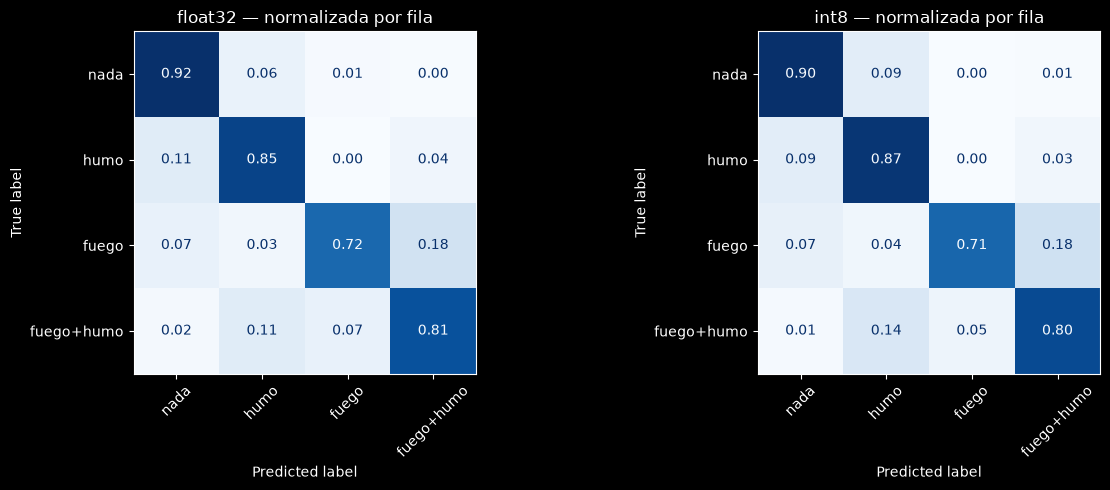

In [10]:
for nombre, pred in [("float32", y_pred), ("int8", y_pred_int8)]:
    print(f"=== {nombre} ===")
    print(classification_report(y_true, pred, target_names=CLASES, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (pred, titulo) in zip(axes, [(y_pred, "float32"), (y_pred_int8, "int8")]):
    ConfusionMatrixDisplay(
        confusion_matrix(combo(y_true), combo(pred), labels=range(len(COMBOS)),
                         normalize="true"),
        display_labels=COMBOS,
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{titulo} — normalizada por fila")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Las tablas de abajo dan recall y precisión **por etiqueta**, con un umbral provisorio de
0,5. Pero al nodo no le importa cada etiqueta por separado: le importa si manda la alerta.
La regla es **alerta si alguna de las dos probabilidades supera el umbral**, y eso separa
dos casos que el recall de `fuego` mete en la misma bolsa: un incendio que la red vio sólo
como humo (la alerta sale igual) y uno que no vio de ninguna forma (la alerta se pierde).
La tabla del umbral de decisión los separa, porque es la que responde la pregunta del
proyecto: **de cada cien incendios, ¿cuántos pasan sin que el nodo diga nada?**

In [11]:
def a_rgb565(imagen):
    '''Color cuantizado a 5/6/5 bits por canal, como lo entrega el OV2640.

    Las imágenes de `test_ds` ya están a 96×96: lo único que falta imitar es la
    profundidad de color del sensor.
    '''
    x = np.clip(np.round(imagen), 0, 255).astype(np.uint16)
    r, g, b = x[..., 0] >> 3, x[..., 1] >> 2, x[..., 2] >> 3      # 5, 6 y 5 bits
    return np.stack([(r << 3) | (r >> 2),                          # 5 bits -> 8
                     (g << 2) | (g >> 4),                          # 6 bits -> 8
                     (b << 3) | (b >> 2)], axis=-1).astype(np.float32)


y_prob_camara = evaluar_int8(test_ds, transformar=a_rgb565)
y_pred_camara = (y_prob_camara >= 0.5).astype(np.uint8)
print("=== int8 sobre RGB565, como lo ve la cámara ===")
print(classification_report(y_true, y_pred_camara, target_names=CLASES, digits=3, zero_division=0))


=== int8 sobre RGB565, como lo ve la cámara ===
              precision    recall  f1-score   support

       fuego      0.943     0.849     0.894      1115
        humo      0.893     0.904     0.899      2081

   micro avg      0.909     0.885     0.897      3196
   macro avg      0.918     0.877     0.896      3196
weighted avg      0.911     0.885     0.897      3196
 samples avg      0.486     0.474     0.475      3196



In [12]:
from sklearn.metrics import precision_score, recall_score

variantes = [("float32 (Keras)", y_pred),
             ("int8 (TFLite)", y_pred_int8),
             ("int8 + RGB565 (cámara)", y_pred_camara)]


def tabla(titulo, mascara):
    '''Recall y precisión por etiqueta, con el umbral provisorio de 0,5.'''
    print(f"\n{titulo}   ({np.sum(mascara)} imágenes)")
    print(f"{'variante':<26}"
          + "".join(f"{'recall ' + c:>14}{'precisión ' + c:>17}" for c in CLASES))
    for nombre, pred in variantes:
        r = recall_score(y_true[mascara], pred[mascara], average=None, zero_division=0)
        p = precision_score(y_true[mascara], pred[mascara], average=None, zero_division=0)
        print(f"{nombre:<26}"
              + "".join(f"{r[i]:>14.3f}{p[i]:>17.3f}" for i in range(len(CLASES))))


tabla("prueba completa", np.ones(len(y_true), bool))
# El número que vale: sin los gemelos del entrenamiento (§6bis del notebook 4) no queda nada que
# memorizar, así que acá se ve la generalización de verdad.
tabla("prueba sin gemelos de entrenamiento", LIMPIO)

print(f"\n.tflite             {len(tflite)} bytes ({len(tflite) / 1024:.0f} kB)")
print("MACs, arena y latencia estimadas: §4 del notebook 4 "
      "(la arena se confirma en placa con arena_used_bytes())")


prueba completa   (4306 imágenes)
variante                    recall fuego  precisión fuego   recall humo   precisión humo
float32 (Keras)                    0.880            0.933         0.901            0.911
int8 (TFLite)                      0.857            0.939         0.920            0.886
int8 + RGB565 (cámara)             0.849            0.943         0.904            0.893

prueba sin gemelos de entrenamiento   (3320 imágenes)
variante                    recall fuego  precisión fuego   recall humo   precisión humo
float32 (Keras)                    0.869            0.929         0.904            0.911
int8 (TFLite)                      0.845            0.935         0.925            0.886
int8 + RGB565 (cámara)             0.836            0.939         0.911            0.892

.tflite             315936 bytes (309 kB)
MACs, arena y latencia estimadas: §4 del notebook 4 (la arena se confirma en placa con arena_used_bytes())


### Umbral de decisión

Hasta acá el umbral fue 0,5 en cada etiqueta: un valor que nadie eligió. Al nodo le
importa una sola pregunta —¿alerto o no?—, así que la regla es **alerta si
max(P(`fuego`), P(`humo`)) ≥ umbral**, y el umbral sale de un objetivo explícito: perder
como mucho `OBJETIVO_PERDIDAS` de los eventos (escenas con fuego, humo o ambos). Entre los
umbrales que lo cumplen se toma el más alto, que es el que menos falsas alarmas dispara.

Cuatro cuidados:

- **Se elige en validación y se mide en prueba.** Elegirlo mirando la prueba es ajustarlo
  a los mismos datos con los que después se lo evalúa.
- **Se elige sobre la validación sin gemelos.** Validación también tiene gemelos de
  entrenamiento (§6bis del notebook 4); con ellos adentro las pérdidas se subestiman y el umbral queda
  corto.
- **Se elige con el modelo desplegado** (int8 + RGB565), no con el float: es su salida la
  que el firmware va a comparar.
- **Viaja al firmware** en `cuantizacion.json`, ya convertido a int8: el nodo compara la
  salida cruda sin decuantizar.

`OBJETIVO_PERDIDAS` es una decisión del proyecto, no de la red: cuántos eventos se tolera
perder a cambio de cuántas falsas alarmas. La tabla muestra las dos caras.

El objetivo se cumple **en validación**, no está garantizado en prueba. Los splits de
D-Fire no tienen exactamente la misma dificultad, y la diferencia entre lo que promete
validación y lo que da prueba es la que hay que esperar al pasar al campo: por eso se
imprimen las dos. Si hace falta margen, la perilla es bajar `OBJETIVO_PERDIDAS`.


In [13]:
# Regla del nodo: alerta si max(P(fuego), P(humo)) >= UMBRAL. Se elige en VALIDACIÓN
# sin gemelos y con el modelo desplegado (int8 + RGB565); la prueba sólo la mide.
# ponytail: un solo umbral sobre el máximo de las dos; si hace falta tratar distinto
# al fuego (alertar antes), el paso siguiente es un umbral por etiqueta.
OBJETIVO_PERDIDAS = 0.05    # perilla del proyecto: fracción de eventos que se tolera perder

p_val = evaluar_int8(val_ds, transformar=a_rgb565).max(axis=1)
evento_val = ETIQUETAS[idx_val].any(axis=1)
# Sólo validación sin gemelos (LIMPIO_VAL, §1): con los gemelos adentro las pérdidas
# se subestiman y el umbral queda mal puesto.

candidatos = np.linspace(0, 1, 201)
perdidas_val = np.array([np.mean(p_val[evento_val & LIMPIO_VAL] < u) for u in candidatos])
falsas_val = np.array([np.mean(p_val[~evento_val & LIMPIO_VAL] >= u) for u in candidatos])
# Subir el umbral pierde más eventos y da menos falsas alarmas. Con u = 0 no se pierde
# ninguno, así que siempre hay un candidato válido: se toma el MÁS ALTO que cumple.
cumple = perdidas_val <= OBJETIVO_PERDIDAS
k = np.flatnonzero(cumple)[-1]
UMBRAL = float(candidatos[k])
print(f"validación sin gemelos: umbral {UMBRAL:.3f} -> pierde {perdidas_val[k]:.1%} de los "
      f"eventos, falsa alarma en {falsas_val[k]:.1%} de las escenas sin evento\n")

p_test = y_prob_camara.max(axis=1)
fuego = (y_true[:, 0] == 1) & LIMPIO
evento = y_true.any(axis=1) & LIMPIO
sin_evento = ~y_true.any(axis=1) & LIMPIO
print("prueba sin gemelos, int8 + RGB565:")
print(f"{'regla':<16}{'evento sin alerta':>19}{'fuego sin alerta':>18}"
      f"{'fuego sólo como humo':>22}{'falsa alarma':>14}")
for nombre, u in [("umbral 0,5", 0.5), (f"umbral {UMBRAL:.3f}", UMBRAL)]:
    alerta = p_test >= u
    # Fuego que la red no vio como fuego pero sí como humo: la alerta sale igual.
    solo_humo = alerta & (y_prob_camara[:, 0] < u)
    print(f"{nombre:<16}{np.mean(~alerta[evento]):>19.1%}{np.mean(~alerta[fuego]):>18.1%}"
          f"{np.mean(solo_humo[fuego]):>22.1%}{np.mean(alerta[sin_evento]):>14.1%}")

# El firmware compara la salida int8 cruda, sin decuantizar. Las dos etiquetas
# comparten tensor de salida, o sea la misma escala y zero_point:
# p >= u  <=>  q >= u / escala + zero_point  <=>  q >= ceil(u / escala + zero_point).
escala, zero_point = det_salida["quantization"]
cuantizacion["decision"] = {
    "regla": "alerta si max(salida_int8[0], salida_int8[1]) >= umbral_int8",
    "umbral": UMBRAL,
    "umbral_int8": int(np.ceil(UMBRAL / escala + zero_point)),
    "objetivo_perdidas_validacion": OBJETIVO_PERDIDAS,
}
(ruta_modelos / "cuantizacion.json").write_text(json.dumps(cuantizacion, indent=2))
print(f"\n{ruta_modelos / 'cuantizacion.json'}: {json.dumps(cuantizacion['decision'])}")

validación sin gemelos: umbral 0.420 -> pierde 4.7% de los eventos, falsa alarma en 13.2% de las escenas sin evento

prueba sin gemelos, int8 + RGB565:
regla             evento sin alerta  fuego sin alerta  fuego sólo como humo  falsa alarma
umbral 0,5                     6.5%              3.1%                 13.3%         11.0%
umbral 0.420                   5.0%              2.2%                 11.6%         13.7%

../salidas/modelos/cuantizacion.json: {"regla": "alerta si max(salida_int8[0], salida_int8[1]) >= umbral_int8", "umbral": 0.42, "umbral_int8": -20, "objetivo_perdidas_validacion": 0.05}


## 4. Entregables

| Archivo | Qué es |
|---|---|
| `salidas/modelos/modelo_int8.cc` | el modelo int8 como array de C (`const`, `alignas(16)`): es lo que se compila en el firmware |
| `salidas/modelos/modelo_int8.tflite` | el mismo modelo, para volver a medirlo sin regenerarlo |
| `salidas/modelos/cuantizacion.json` | escala y `zero_point` de entrada y salida (sin esos dos números el firmware no pasa de int8 a probabilidad) y la **regla de decisión**: el umbral sobre la mayor de las dos salidas, ya convertido a int8 (§3) |

El `.keras` que entró es un *checkpoint* del entrenamiento, no un entregable. Las ops a
registrar en el `MicroMutableOpResolver` salen de §2; el reparto de memoria (flash / SRAM
interna / PSRAM), del §4 del notebook 4.

In [14]:
(ruta_modelos / "modelo_int8.tflite").write_bytes(tflite)

for ruta in sorted(ruta_modelos.iterdir()):
    print(f"{ruta.name:<45}{ruta.stat().st_size / 1024:>9.1f} kB")

cnn_fuego_epochs_82_image_size_96x96.keras      1176.8 kB
cuantizacion.json                                  0.5 kB
modelo_int8.cc                                  1954.2 kB
modelo_int8.tflite                               308.5 kB
v1                                                 0.2 kB


## 5. Conclusiones

- **La métrica de despliegue es la alerta, no el recall por etiqueta.** Un incendio visto
  sólo como humo no pierde la alerta; uno en el que no se enciende ninguna salida, sí. §3
  separa los dos, y el umbral de decisión se fija contra ese objetivo, en validación y
  con el modelo int8 + RGB565.
- **`humo` fue la clase floja y la que más sufrió la cuantización** en el modelo anterior
  de 3 clases: al pasar a int8 perdía varias veces lo que perdía `fuego`, mientras que la
  profundidad de color RGB565 les costaba lo mismo a las dos (~1,5 puntos). Por eso la
  calibración int8 pasó a 500 imágenes por combinación (§2). Hay que confirmar que se
  sostiene con el modelo multi-etiqueta, donde `humo` ya no es la misma tarea.
- **Despliegue en el nodo: el cambio de arquitectura está hecho.** La CNN de cuatro bloques
  del comienzo (1,1 M de parámetros, 845 MMAC, ~8 s por inferencia en el S3) quedó
  reemplazada por MobileNetV1 α=0.25 a 96×96: ~7,5 MMAC, ~206 kB de pesos int8 (~310 kB
  el `.tflite` exportado, con las escalas per-channel) y ~57 ms estimados, que entran en
  SRAM interna (§4 del notebook 4 y §2 de este). Son números del modelo analítico, no medidos: falta lo que no se
  puede estimar desde la notebook —latencia y consumo reales en placa,
  `arena_used_bytes()` y el desempeño con la cámara del nodo—.